In [1]:
%load_ext autoreload
%autoreload 2

In [96]:
import os, sys
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt
import geopandas as gpd
import shapely
import pandas as pd
from geodatasets import get_path
import ast
# import geopy.distances
from tqdm import tqdm
from sklearn.linear_model import LinearRegression
from sklearn.decomposition import PCA
from sklearn.metrics import r2_score
from sklearn.model_selection import ShuffleSplit, KFold
from scipy.stats import zscore
import seaborn as sns
import matplotlib as mpl
from matplotlib.colors import ListedColormap
sys.path.append('../src/')
sys.path.append('../content/')
import data_utils as du
import vis_utils as vu
import sample_locations as sl

## Set `data_folder` and plot example:

In [16]:
## Set data folder to the parent folder with the subfolders for each modality (e.g. alphaearth, dynamicworld, tessera):
data_folder = '/Users/tplas/data/dw_sampled_locations/data_spherical/'

list_ids, modality_folders, gdf_points = du.get_list_complete_ids(data_folder)
print(f'Number of samples: {len(list_ids)}')
countries = gpd.read_file('/Users/tplas/data/ne_110m_admin_0_countries/ne_110m_admin_0_countries.shp')


Sample random_sample has 9695 data points out of 18393.
Sample lc_stratified_sample has 9693 data points out of 18393.
Number of samples: 18393


In [72]:
df_all, col_names = du.merge_modalities(parent_folder=data_folder, sample_type='lc_stratified_sample', zscore_embeddings=True)


Sample random_sample has 9695 data points out of 18393.
Sample lc_stratified_sample has 9693 data points out of 18393.


Text(50.72222222222221, 0.5, 'Regressor')

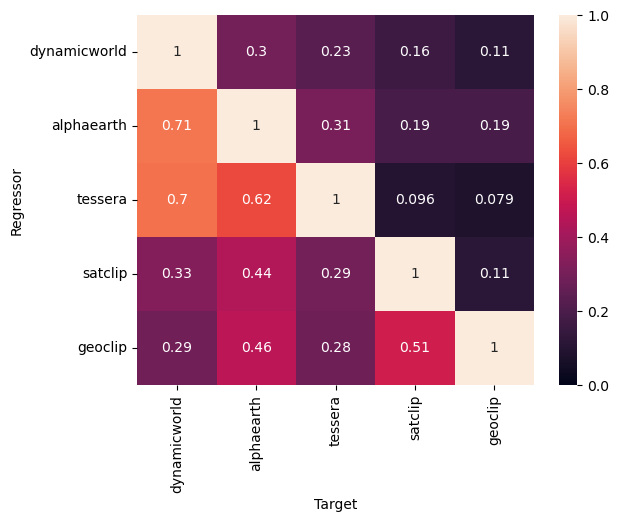

In [98]:
## regression:

def get_r2_regression(df_all, col_names, regressor, target, n_splits=4, equalize_ambient_dim=False):
    df_all = df_all.copy()
    data_regressor = df_all[col_names[regressor]].values
    data_target = df_all[col_names[target]].values
    assert data_regressor.shape[0] == data_target.shape[0]
    if equalize_ambient_dim and regressor != 'dynamicworld' and target != 'dynamicworld':
        if data_regressor.shape[1] > data_target.shape[1]:
            pca = PCA(n_components=data_target.shape[1])
            data_regressor = pca.fit_transform(data_regressor)
        elif data_target.shape[1] > data_regressor.shape[1]:
            pca = PCA(n_components=data_regressor.shape[1])
            data_target = pca.fit_transform(data_target)
        

    if n_splits > 1:
        rs = KFold(n_splits=n_splits, shuffle=True, random_state=0)
        mse_per_point = np.zeros(len(df_all))
        r2 = np.zeros(n_splits)
        for i, (train_index, test_index) in enumerate(rs.split(df_all)):
            
            X_train = data_regressor[train_index]
            Y_train = data_target[train_index]
            X_test = data_regressor[test_index]
            Y_test = data_target[test_index]
        
            reg = LinearRegression().fit(X_train, Y_train)
            Y_pred = reg.predict(X_test)
            r2[i] = r2_score(Y_test, Y_pred)    
            mse_per_point[test_index] = np.mean((Y_test - Y_pred) ** 2, axis=1)
    elif n_splits == 1:
        X = data_regressor
        Y = data_target
        reg = LinearRegression().fit(X, Y)
        Y_pred = reg.predict(X)
        r2 = r2_score(Y, Y_pred)    
        mse_per_point = np.mean((Y - Y_pred) ** 2, axis=1)
    df_all[f'{regressor}_to_{target}_mse'] = mse_per_point
    return np.mean(r2), df_all

mods = list(col_names.keys())
n_mod = len(mods)
r2_matrix = np.zeros((n_mod, n_mod))
for i, regressor in enumerate(mods):
    for j, target in enumerate(mods):
        r2_matrix[i,j], mse = get_r2_regression(df_all, col_names, regressor, target, n_splits=3,
        equalize_ambient_dim=True)

sns.heatmap(r2_matrix, xticklabels=mods, yticklabels=mods, annot=True, vmin=0, vmax=1)
plt.xlabel('Target')
plt.ylabel('Regressor')

<Axes: >

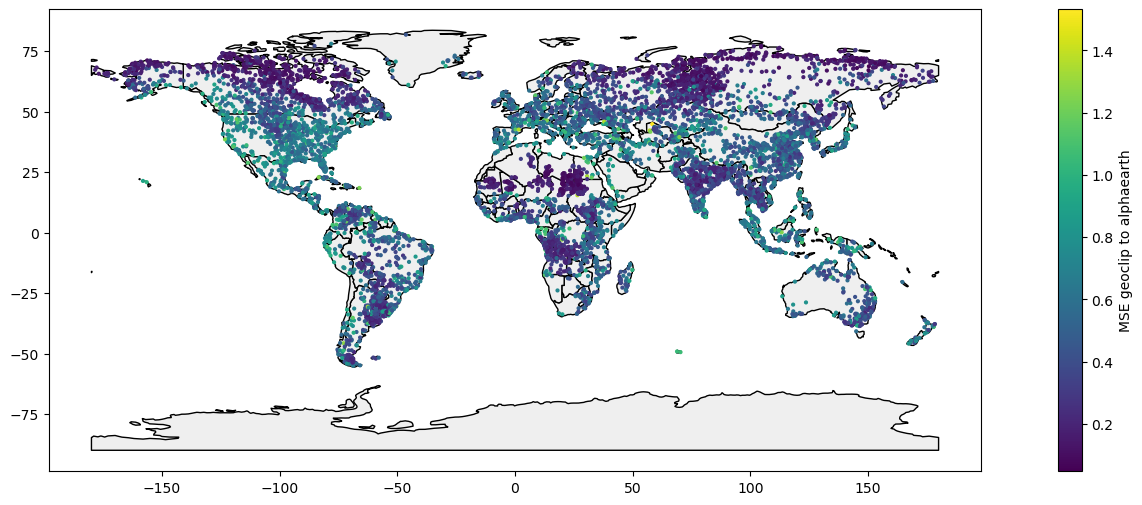

In [99]:
regressor = 'geoclip'
target = 'alphaearth'
 
r2, gdf_tmp = get_r2_regression(df_all, col_names, regressor, target, n_splits=1)
gdf_tmp = gpd.GeoDataFrame(gdf_tmp, geometry=gpd.points_from_xy(gdf_tmp['lon'], gdf_tmp['lat']), crs='EPSG:4326')
fig, ax = plt.subplots(figsize=(20,6))
countries.plot(ax=ax, color="#EFEFEF", edgecolor='black')
gdf_tmp.plot(column=f'{regressor}_to_{target}_mse', cmap='viridis', legend=True, markersize=4, ax=ax,
             legend_kwds={'label': f'MSE {regressor} to {target}'})


<Axes: >

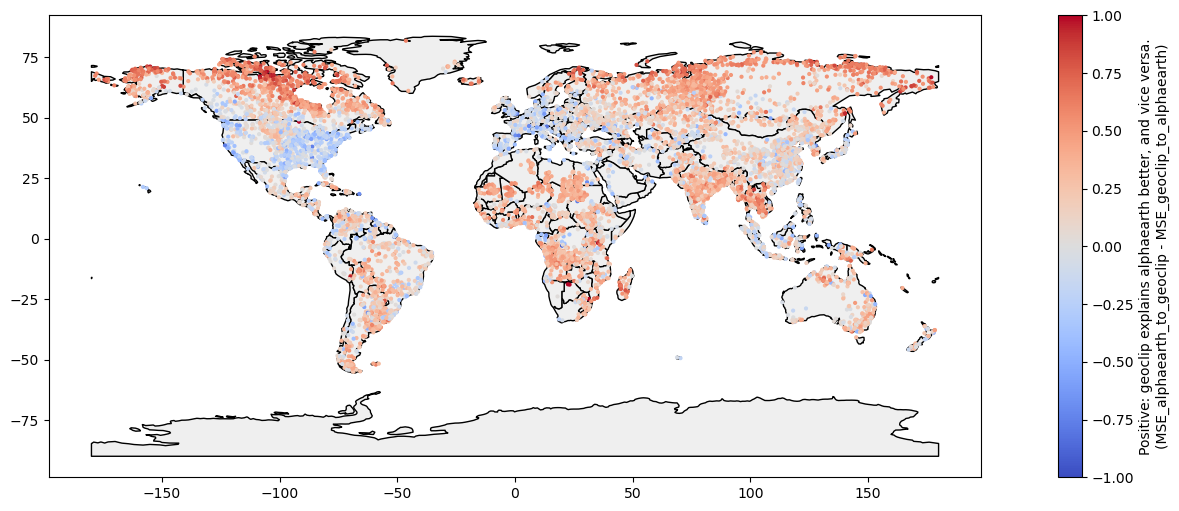

In [133]:
pair = ['alphaearth', 'geoclip']
n_splits = 3
equalize_ambient_dim = False

_, gdf_1 = get_r2_regression(df_all, col_names, pair[0], pair[1], n_splits=n_splits, equalize_ambient_dim=equalize_ambient_dim)
gdf_1 = gpd.GeoDataFrame(gdf_1, geometry=gpd.points_from_xy(gdf_1['lon'], gdf_1['lat']), crs='EPSG:4326')
_, gdf_2 = get_r2_regression(df_all, col_names, pair[1], pair[0], n_splits=n_splits, equalize_ambient_dim=equalize_ambient_dim)
gdf_2 = gpd.GeoDataFrame(gdf_2, geometry=gpd.points_from_xy(gdf_2['lon'], gdf_2['lat']), crs='EPSG:4326')

## If positive, the 0->1 error is higher than the 1->0 error, and vice versa if negative.
## Hence, if positive, it means that 1 is better at predicting 0 than the other way around.
gdf_1[f'diff_mse_{pair[0]}_{pair[1]}'] = gdf_1[f'{pair[0]}_to_{pair[1]}_mse'] - gdf_2[f'{pair[1]}_to_{pair[0]}_mse']


fig, ax = plt.subplots(figsize=(20,6))
countries.plot(ax=ax, color="#EFEFEF", edgecolor='black')
gdf_1.plot(column=f'diff_mse_{pair[0]}_{pair[1]}', cmap='coolwarm', 
            vmin=-1, vmax=1, legend=True, markersize=4, ax=ax,
            legend_kwds={'label': f'Positive: {pair[1]} explains {pair[0]} better, and vice versa.' +
            f'\n(MSE_{pair[0]}_to_{pair[1]} - MSE_{pair[1]}_to_{pair[0]})'})


## Next:
- Dim per AE/T patch, plot per point. Does any of the emb->emb performance correlate with dim (eg low dim in sahara)


In [ ]:
def get_list_dims(parent_folder=data_folder, sample_type='lc_stratified_sample', modality='alphaearth'):
    list_ids, modality_folders, gdf_points = du.get_list_complete_ids(parent_folder)
    if modality == 'alphaearth':
        suffix = '_alphaearth_y-2024.tif'
    else:
        raise ValueError(f'Modality {modality} not supported.')
    dict_results = {x: [] for x in ['id', 'dim']}
    for id_patch in tqdm(list_ids):
        path_modality = os.path.join(modality_folders[modality], f'{id_patch}{suffix}')
        if os.path.exists(path_modality):
            im = du.load_tiff(path_modality, datatype='np')
            im = im.reshape(im.shape[0], -1).T
            assert im.shape[0] > im.shape[1], f'Number of samples {im.shape[0]} should be greater than number of features {im.shape[1]} for PCA to work properly.'
            pca = PCA(n_components=im.shape[1])
            pca.fit(im)
            sum_squares = np.sum(np.power(pca.explained_variance_, 2))
            square_sum = np.sum(pca.explained_variance_) ** 2
            dim = float(square_sum / sum_squares)
            # return pca

            dict_results['id'].append(int(id_patch))
            dict_results['dim'].append(dim)
    return dict_results


tmp = get_list_dims()

Sample random_sample has 9695 data points out of 18393.
Sample lc_stratified_sample has 9693 data points out of 18393.


 16%|█▌        | 2965/18393 [00:26<02:16, 113.10it/s]/opt/anaconda3/envs/neureo/lib/python3.12/site-packages/sklearn/decomposition/_pca.py:646: RuntimeWarning: invalid value encountered in divide
  explained_variance_ratio_ = explained_variance_ / total_var
/var/folders/kh/y9z_055x6gq8gc74b6y16r1c0000gn/T/ipykernel_36886/2871434987.py:18: RuntimeWarning: invalid value encountered in scalar divide
  dim = float(square_sum / sum_squares)
 21%|██        | 3810/18393 [00:33<02:04, 116.90it/s]/opt/anaconda3/envs/neureo/lib/python3.12/site-packages/sklearn/decomposition/_pca.py:646: RuntimeWarning: invalid value encountered in divide
  explained_variance_ratio_ = explained_variance_ / total_var
/var/folders/kh/y9z_055x6gq8gc74b6y16r1c0000gn/T/ipykernel_36886/2871434987.py:18: RuntimeWarning: invalid value encountered in scalar divide
  dim = float(square_sum / sum_squares)
100%|██████████| 18393/18393 [02:38<00:00, 116.11it/s]


<Axes: >

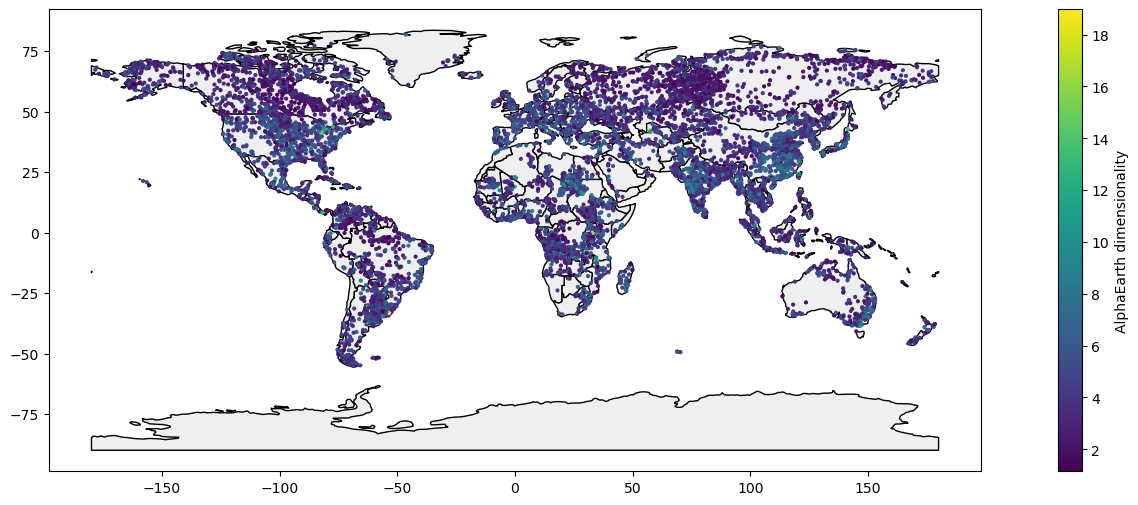

In [128]:
df_dim = pd.DataFrame(tmp)
array_dim = np.array([df_dim[df_dim['id'] == id_patch]['dim'].values[0] for id_patch in gdf_1.id])
gdf_1['ae_dim'] = array_dim


fig, ax = plt.subplots(figsize=(20,6))
countries.plot(ax=ax, color="#EFEFEF", edgecolor='black')
gdf_1.plot(column=f'ae_dim', cmap='viridis', legend=True, markersize=4, ax=ax,
             legend_kwds={'label': f'AlphaEarth dimensionality'})

In [132]:
np.corrcoef(gdf_1.ae_dim, gdf_1.diff_mse_alphaearth_geoclip)

array([[ 1.        , -0.11570172],
       [-0.11570172,  1.        ]])

In [130]:
gdf_1.columns

Index(['id', 'lat', 'lon', 'water', 'trees', 'grass', 'flooded_vegetation',
       'crops', 'shrub_and_scrub', 'built',
       ...
       'geoclip_emb_506', 'geoclip_emb_507', 'geoclip_emb_508',
       'geoclip_emb_509', 'geoclip_emb_510', 'geoclip_emb_511',
       'alphaearth_to_geoclip_mse', 'geometry', 'diff_mse_alphaearth_geoclip',
       'ae_dim'],
      dtype='object', length=976)